In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file dữ liệu đã làm sạch
df = pd.read_csv('bank_data_cleaned.csv')

# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Xem qua 5 dòng đầu
print(df.head())

    age         job  marital  education default  balance housing loan  \
0  59.0      Admin.  Married  Secondary      No   2343.0     Yes   No   
1  56.0      Admin.  Married  Secondary      No     45.0      No   No   
2  41.0  Technician  Married  Secondary      No   1270.0     Yes   No   
3  55.0    Services  Married  Secondary      No   2476.0     Yes   No   
4  54.0      Admin.  Married   Tertiary      No    184.0      No   No   

   contact  day month  duration  campaign  pdays  previous      poutcome  \
0  Unknown    5   May    1042.0         1     -1         0  New Customer   
1  Unknown    5   May    1467.0         1     -1         0  New Customer   
2  Unknown    5   May    1389.0         1     -1         0  New Customer   
3  Unknown    5   May     579.0         1     -1         0  New Customer   
4  Unknown    5   May     673.0         2     -1         0  New Customer   

  deposit  
0     Yes  
1     Yes  
2     Yes  
3     Yes  
4     Yes  


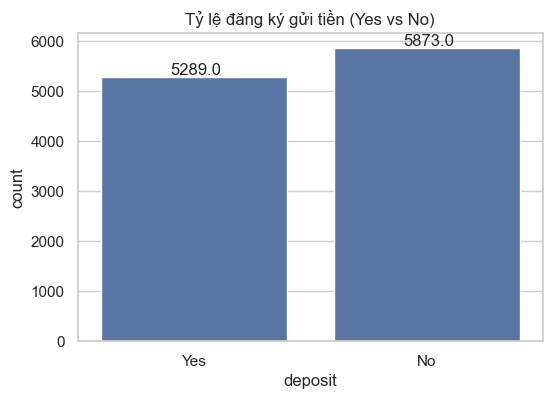

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='deposit')
plt.title('Tỷ lệ đăng ký gửi tiền (Yes vs No)')
# Thêm số lượng cụ thể lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+50))
plt.show()

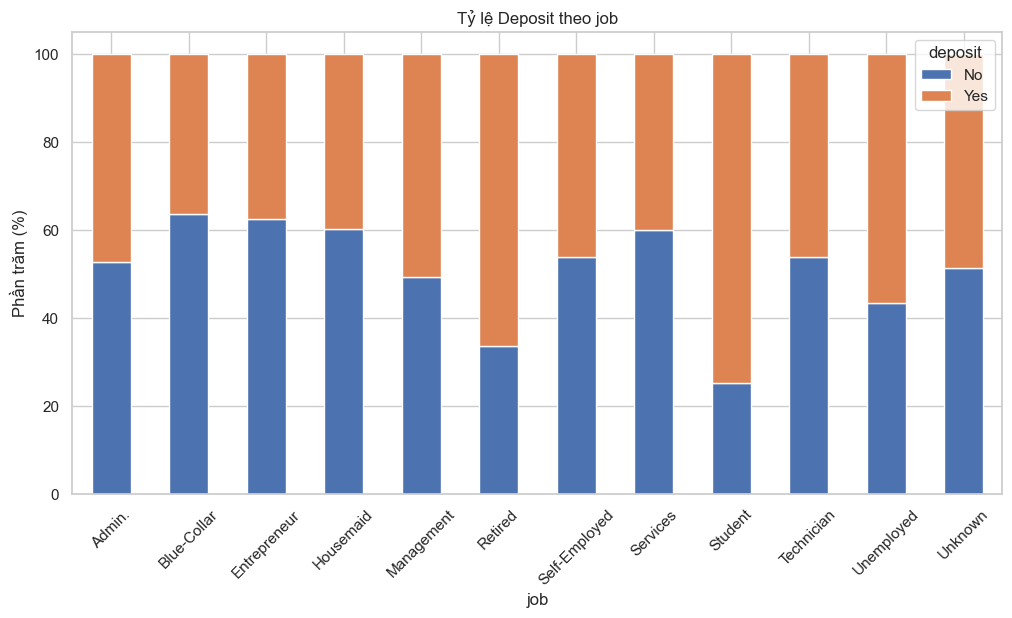

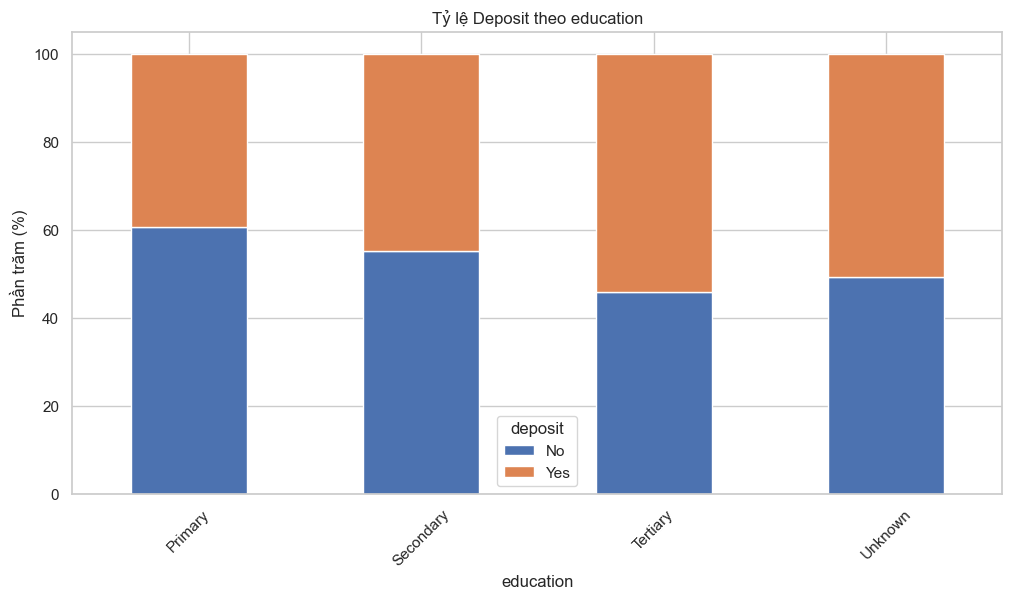

In [12]:
def plot_stacked_bar(column):
    ct = pd.crosstab(df[column], df['deposit'], normalize='index') * 100
    ax = ct.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title(f'Tỷ lệ Deposit theo {column}')
    plt.ylabel('Phần trăm (%)')
    plt.xticks(rotation=45)
    plt.show()

# Chạy thử cho Nghề nghiệp và Học vấn
plot_stacked_bar('job')
plot_stacked_bar('education')

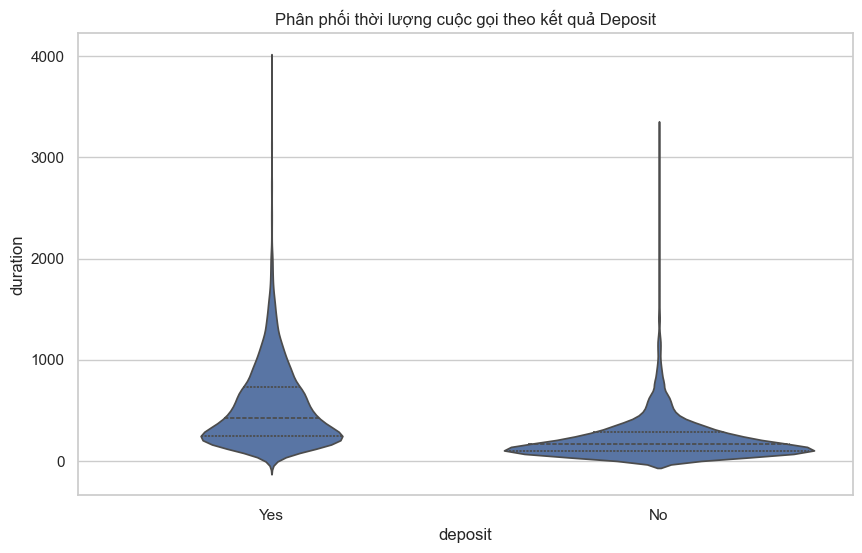

In [13]:
# Mở rộng: Sử dụng Violin Plot để thấy cả phân phối và Boxplot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='deposit', y='duration', inner="quartile")
plt.title('Phân phối thời lượng cuộc gọi theo kết quả Deposit')
plt.show()

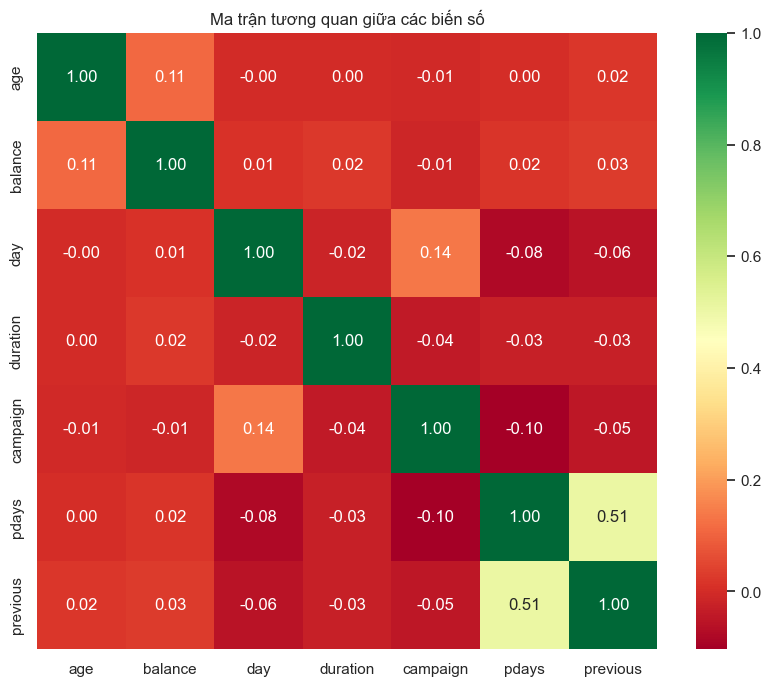

In [14]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

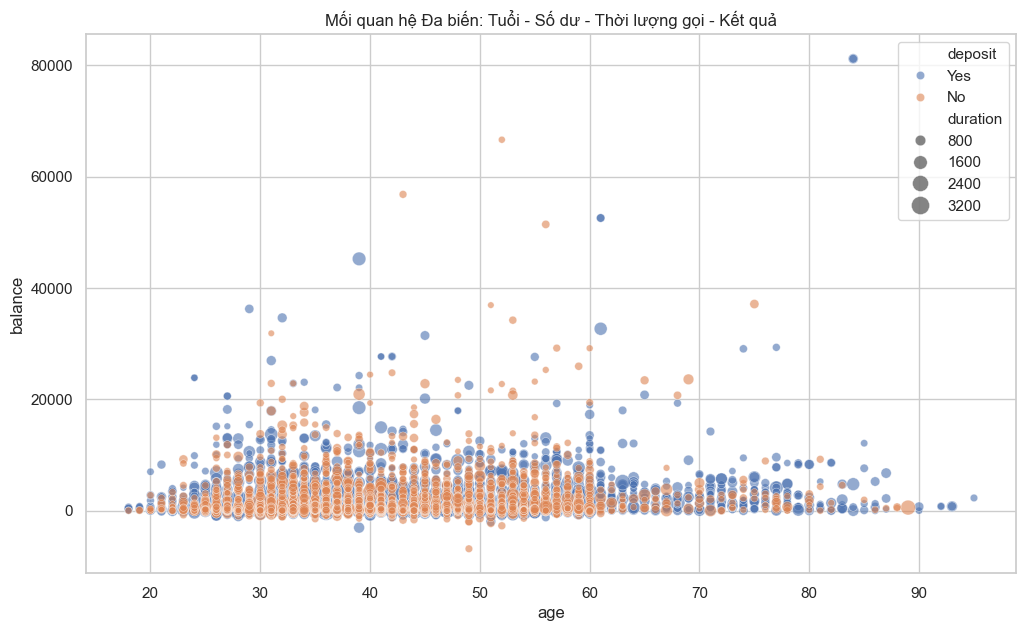

In [15]:
# Mở rộng: Scatter plot kết hợp Age, Balance và màu sắc theo Deposit
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='age', y='balance', hue='deposit', size='duration', alpha=0.6, sizes=(20, 200))
plt.title('Mối quan hệ Đa biến: Tuổi - Số dư - Thời lượng gọi - Kết quả')
plt.show()

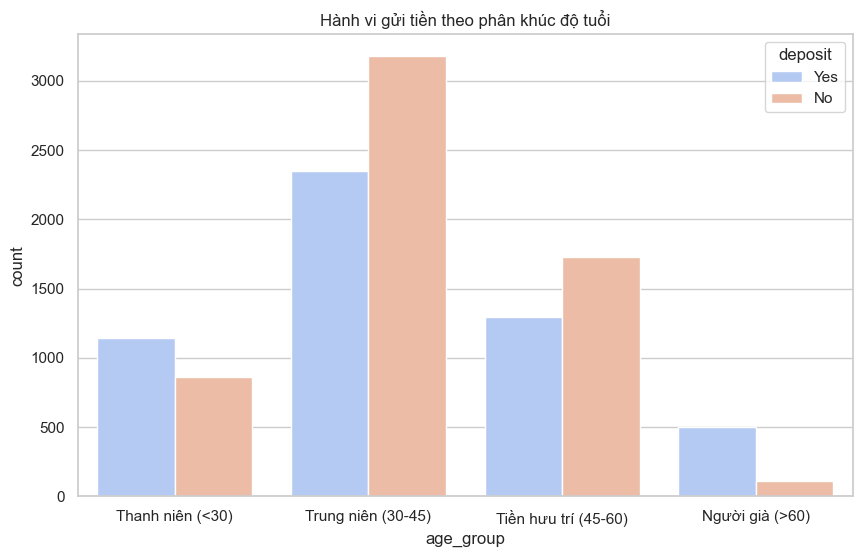

In [16]:
# Tạo các nhóm độ tuổi
bins = [0, 30, 45, 60, 100]
labels = ['Thanh niên (<30)', 'Trung niên (30-45)', 'Tiền hưu trí (45-60)', 'Người già (>60)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Vẽ biểu đồ tỷ lệ gửi tiền theo nhóm tuổi
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='deposit', palette='coolwarm')
plt.title('Hành vi gửi tiền theo phân khúc độ tuổi')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6104\2326962673.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='duration', hue='deposit', shade=True, palette='husl', common_norm=False)


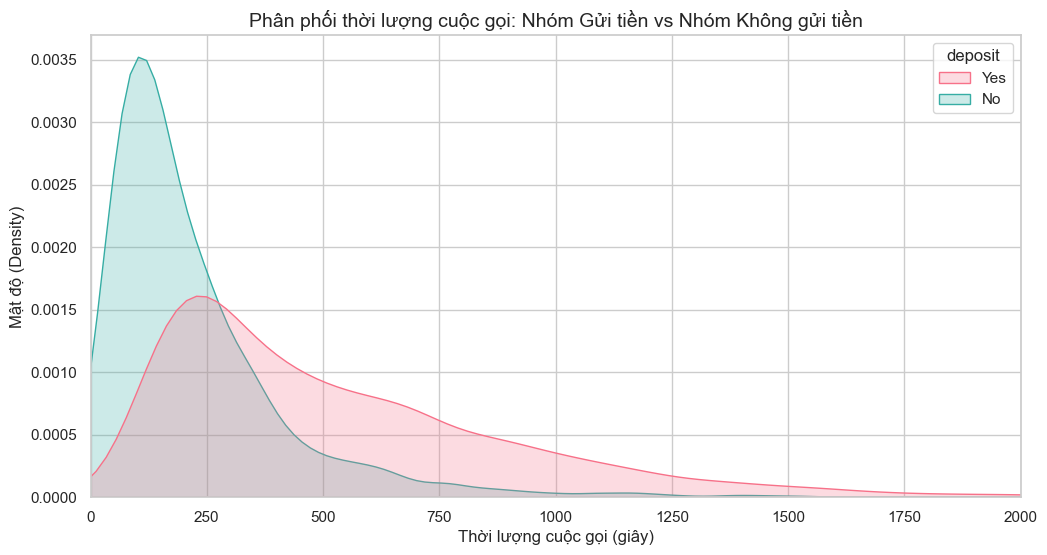

In [17]:

# Vẽ biểu đồ phân phối cho nhóm Yes và No
sns.kdeplot(data=df, x='duration', hue='deposit', shade=True, palette='husl', common_norm=False)

plt.title('Phân phối thời lượng cuộc gọi: Nhóm Gửi tiền vs Nhóm Không gửi tiền', fontsize=14)
plt.xlabel('Thời lượng cuộc gọi (giây)')
plt.ylabel('Mật độ (Density)')
plt.xlim(0, 2000) # Giới hạn lại để dễ nhìn vì các cuộc gọi quá dài thường ít
plt.show()

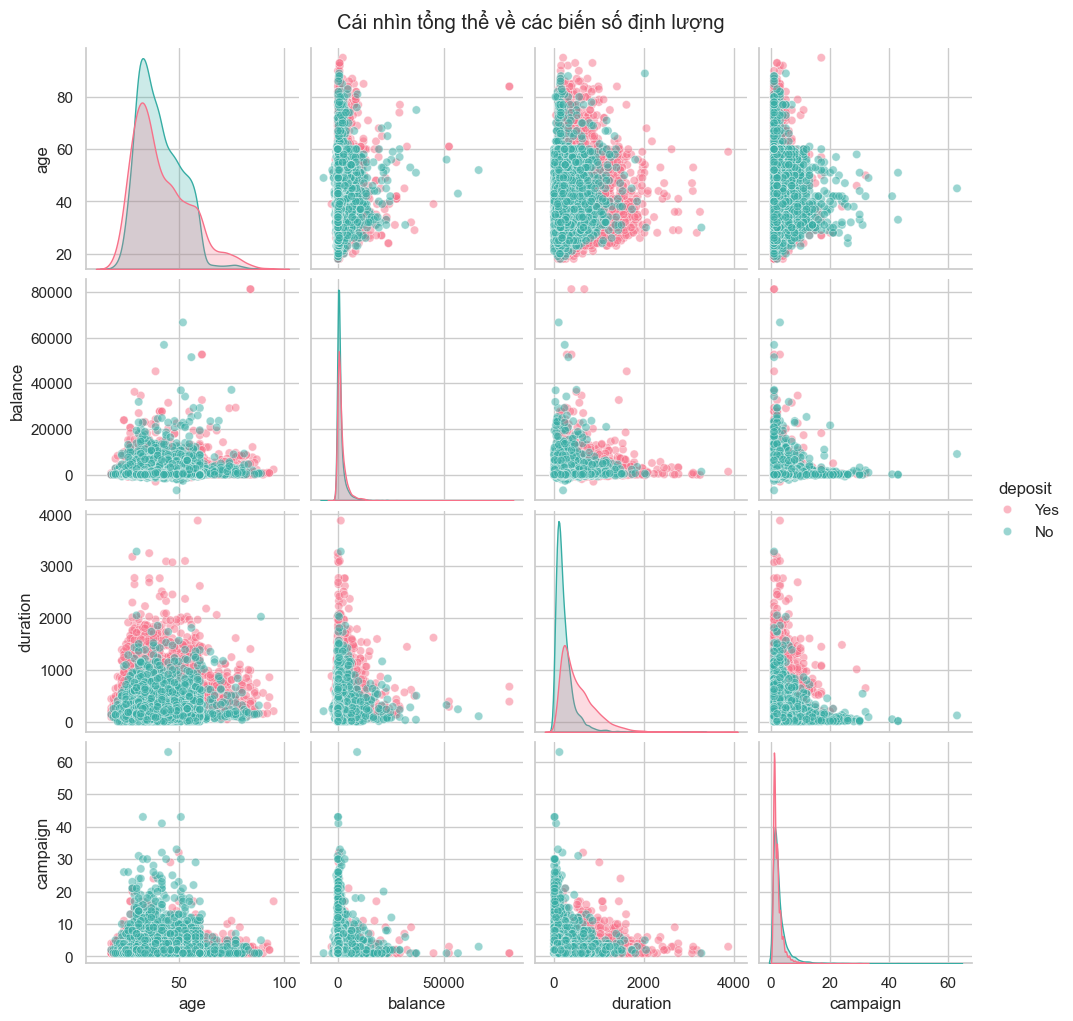

In [18]:
# Chọn các biến quan trọng nhất để soi
target_vars = ['age', 'balance', 'duration', 'campaign', 'deposit']
sns.pairplot(df[target_vars], hue='deposit', palette='husl', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Cái nhìn tổng thể về các biến số định lượng', y=1.02)
plt.show()